# 09 — The catch check: true (mark-to-market) drawdown + 2026

Two skeptic checks:
1. **Real drawdown** — mark OPEN shorts to market every minute, not just at
   close. This is the pain you'd actually see on screen (esp. the Feb cluster).
2. **2026** — a third, untouched period (Jan-Apr, 140 symbols). Same rule.

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *
import heapq

PRE, EXIT, STOP = 60, 240, 0.03
CAPITAL, SIZE, COST = 1000.0, 20.0, 0.0015

def pnl_and_exit(P, stop):
    p0 = P[:, 0]; thr = p0 * (1 + stop)
    n, L = P.shape; pnl = np.empty(n); off = np.full(n, L - 1)
    for i in range(n):
        w = int(np.argmax(P[i] >= thr[i]))
        if w > 0 and P[i, w] >= thr[i]:
            off[i] = w
        pnl[i] = 1.0 - P[i, off[i]] / p0[i]
    return pnl, off

def load(year):
    paths = np.load(f'_out/pump_paths_{year}.npy') if year != 2024 else np.load('_out/pump_paths.npy')
    ts = np.load(f'_out/pump_ts_{year}.npy') if year != 2024 else None
    P = (1.0 + paths)[:, PRE:PRE + EXIT + 1]
    return P, ts

In [2]:
def portfolio_mtm(P, ts):
    """$1000/$20 sim; returns realized & mark-to-market equity on a minute grid."""
    pnl, off = pnl_and_exit(P, STOP)
    emin = ((ts - ts.min()) // (60 * 10**9)).astype(int)     # entry minute index
    xmin = emin + off
    order = np.argsort(emin)
    # event sim: which trades get taken under the capital cap
    eq = CAPITAL; comm = 0.0; op = []; taken = np.zeros(len(pnl), bool); maxc = 0
    for k in order:
        now = emin[k]
        while op and op[0][0] <= now:
            _, d = heapq.heappop(op); eq += d; comm -= SIZE
        if eq - comm >= SIZE:
            heapq.heappush(op, (xmin[k], SIZE * (pnl[k] - COST))); comm += SIZE
            taken[k] = True; maxc = max(maxc, len(op))
    # minute-grid realized + unrealized
    T = int(xmin.max()) + 2
    rdelta = np.zeros(T); unreal = np.zeros(T)
    for k in np.where(taken)[0]:
        e, xo = emin[k], off[k]; xi = e + xo
        rdelta[xi] += SIZE * (pnl[k] - COST)
        unreal[e:xi] += SIZE * (1.0 - P[k, :xo] / P[k, 0])   # marked while open
    realized = CAPITAL + np.cumsum(rdelta)
    mtm = realized + unreal
    def maxdd(x):
        return (x / np.maximum.accumulate(x) - 1).min() * 100
    return dict(pnl=pnl, off=off, taken=taken, maxc=maxc,
                realized=realized, mtm=mtm, t0=ts.min(),
                dd_real=maxdd(realized), dd_mtm=maxdd(mtm),
                final=realized[-1])

P25, ts25 = load(2025)
R = portfolio_mtm(P25, ts25)
print(f'2025: final ${R["final"]:,.0f}  ({(R["final"]/CAPITAL-1)*100:+.0f}%)')
print(f'  realized maxDD : {R["dd_real"]:.1f}%')
print(f'  TRUE MTM maxDD : {R["dd_mtm"]:.1f}%   <-- the real on-screen pain')
print(f'  max concurrent : {R["maxc"]}')

2025: final $1,769  (+77%)
  realized maxDD : -6.3%
  TRUE MTM maxDD : -9.3%   <-- the real on-screen pain
  max concurrent : 62


[saved] notebooks\_out\09_mtm_2025.png


WindowsPath('C:/projects/researchlab/notebooks/_out/09_mtm_2025.png')

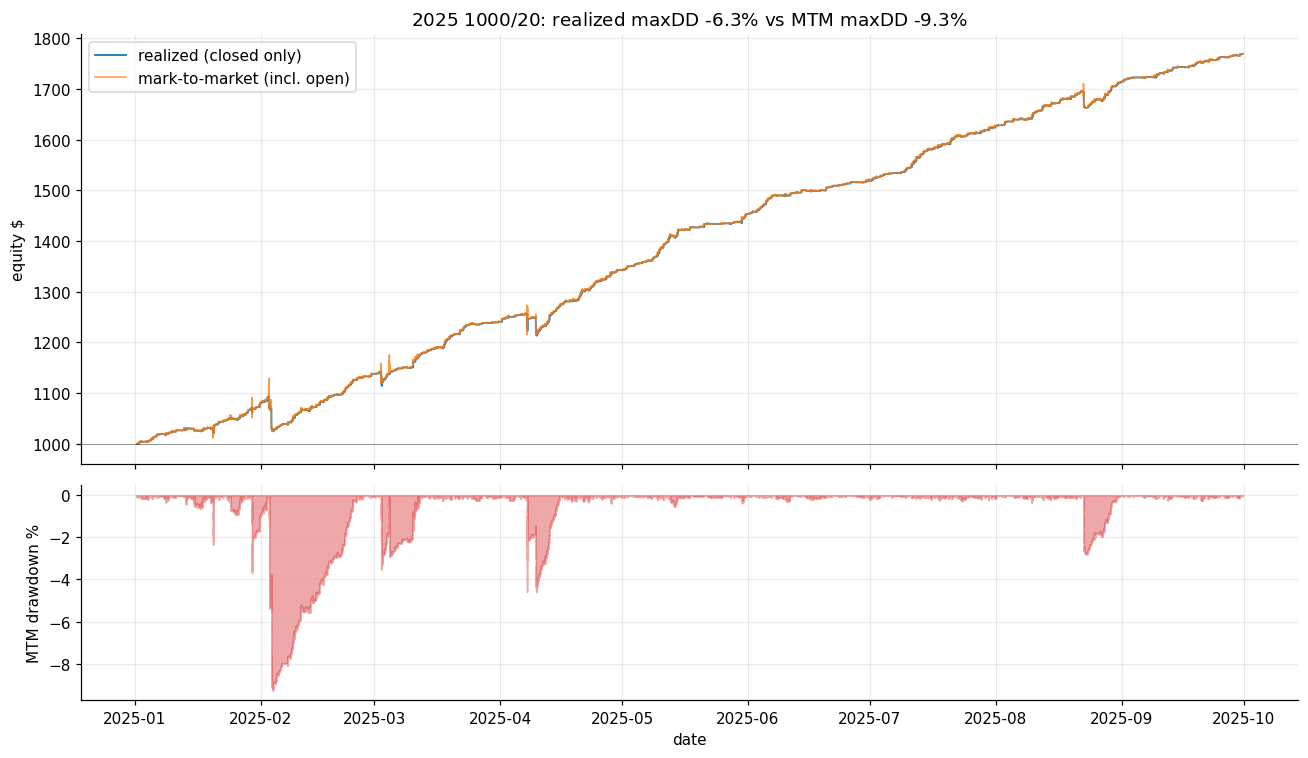

In [3]:
idx = pd.to_datetime(R['t0']) + pd.to_timedelta(np.arange(len(R['mtm'])), 'm')
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios':[2,1]})
a1.plot(idx, R['realized'], lw=1.2, label='realized (closed only)')
a1.plot(idx, R['mtm'], lw=1.0, alpha=0.8, label='mark-to-market (incl. open)')
a1.axhline(CAPITAL, color='k', lw=0.6, alpha=0.4); a1.set_ylabel('equity $'); a1.legend()
a1.set_title(f'2025 $1000/$20: realized maxDD {R["dd_real"]:.1f}% vs MTM maxDD {R["dd_mtm"]:.1f}%')
ddm = (R['mtm']/np.maximum.accumulate(R['mtm'])-1)*100
a2.fill_between(idx, ddm, 0, color='tab:red', alpha=0.4)
a2.set_ylabel('MTM drawdown %'); a2.set_xlabel('date')
show('09_mtm_2025')

## 2026 — third independent period (Jan-Apr, 140 symbols)

In [4]:
def stats(p):
    return (len(p), p.mean()*100, np.median(p)*100, (p>0).mean()*100, p.std()*100,
            np.quantile(p,.1)*100, p.mean()/p.std())
HDR=f"{'period':<10}{'n':>6}{'mean':>8}{'median':>8}{'win%':>7}{'std':>8}{'q10':>8}{'m/std':>7}"
def row(name,p):
    n,m,md,w,sd,q,sh=stats(p)
    print(f"{name:<10}{n:>6}{m:>+7.2f}%{md:>+7.2f}%{w:>6.1f}%{sd:>7.2f}%{q:>+7.2f}%{sh:>7.3f}")

P24,_ = load(2024); P26, ts26 = load(2026)
pnl24,_ = pnl_and_exit(P24, STOP)
pnl26,_ = pnl_and_exit(P26, STOP)
print(HDR)
row('2024', pnl24); row('2025', R['pnl']); row('2026', pnl26)

period         n    mean  median   win%     std     q10  m/std
2024         766  +1.39%  +1.11%  56.5%   4.86%  -3.76%  0.286
2025        2178  +1.67%  +1.34%  56.6%   5.16%  -3.53%  0.324
2026         971  +2.05%  +0.78%  53.6%   5.77%  -3.49%  0.356


2026 portfolio $1000/$20:
  final $1,425  (+43% over 4 months)
  realized maxDD -3.2%   MTM maxDD -3.6%   max concurrent 56


[saved] notebooks\_out\09_portfolio_2026.png


WindowsPath('C:/projects/researchlab/notebooks/_out/09_portfolio_2026.png')

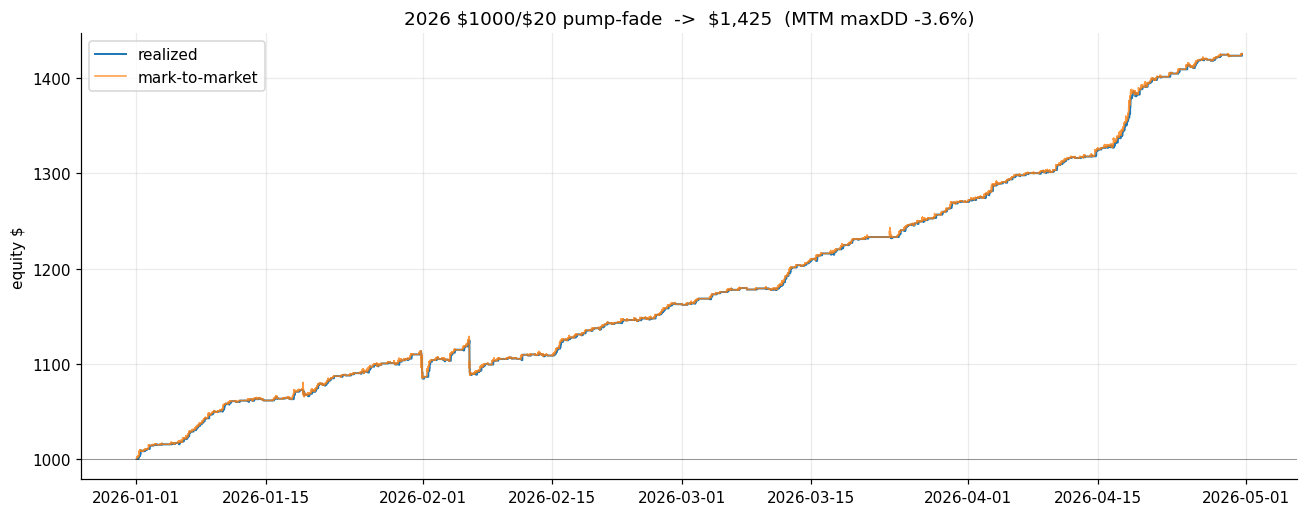

In [5]:
R26 = portfolio_mtm(P26, ts26)
mo = 4  # months in 2026 sample
print(f'2026 portfolio $1000/$20:')
print(f'  final ${R26["final"]:,.0f}  ({(R26["final"]/CAPITAL-1)*100:+.0f}% over {mo} months)')
print(f'  realized maxDD {R26["dd_real"]:.1f}%   MTM maxDD {R26["dd_mtm"]:.1f}%   max concurrent {R26["maxc"]}')

idx26 = pd.to_datetime(R26['t0']) + pd.to_timedelta(np.arange(len(R26['mtm'])), 'm')
fig, ax = plt.subplots(figsize=(12,4.8))
ax.plot(idx26, R26['realized'], lw=1.3, label='realized')
ax.plot(idx26, R26['mtm'], lw=1.0, alpha=0.8, label='mark-to-market')
ax.axhline(CAPITAL, color='k', lw=0.6, alpha=0.4); ax.set_ylabel('equity $'); ax.legend()
ax.set_title(f'2026 $1000/$20 pump-fade  ->  ${R26["final"]:,.0f}  (MTM maxDD {R26["dd_mtm"]:.1f}%)')
show('09_portfolio_2026')